# AML-3303 Assessment 1 – Customer Churn Prediction & Slack Alerts

### Submitted by: Mayur Bhawsar [C0958076]

## 1. Context
ConnectWave Telecom is a growing telecommunications service provider with over 50,000 active customers across urban and semi-urban regions. Over the past year, the company has observed a steady increase in customer churn, especially among prepaid and short-term contract users.

Despite offering competitive pricing and bundled services, ConnectWave struggles to understand why customers leave and which users are most at risk. This uncertainty has resulted in ineffective retention campaigns, higher marketing costs, and declining customer loyalty.

The management team wants to introduce a data-driven monitoring system that can predict churn early and automatically notify the customer retention team through Slack.

## 2. Problem Statement
You have been hired as a Data Scientist at ConnectWave Telecom to help the analytics team reduce customer churn.

Currently, the company identifies churn only after customers have already discontinued their services. This reactive approach leads to:

* Loss of recurring revenue
* Increased customer acquisition costs
* Poor customer experience
* Inefficient use of retention resources

Your responsibility is to build an end-to-end machine learning system that predicts which customers are likely to churn and sends automatic Slack notifications when high-risk customers are detected.

This system will allow the company to intervene early by offering personalized discounts, improved service plans, or loyalty benefits.

## 3. Objective
1. Analyze customer behaviour and service usage patterns to identify major drivers of churn.
2. Build a predictive model to classify whether a customer is likely to churn.
3. Integrate Slack alerts to notify teams about high-risk customers.
4. Provide actionable insights to improve customer retention strategies.

## 4. Data Understanding

In [205]:
import os
import requests

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

In [ ]:
# Load dataset
df = pd.read_csv('../../data/connectwave_customer_churn_dataset.csv')

print("Shape of the dataset: ", df.shape)
df.head()

Shape of the dataset:  (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Categorizing available columns into logical groups:

* **Demographics**: gender, SeniorCitizen, Partner, Dependents.

* **Services Subscribed**: PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies.

* **Account Information**: tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges.

* **Target**: Churn.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Categorical features

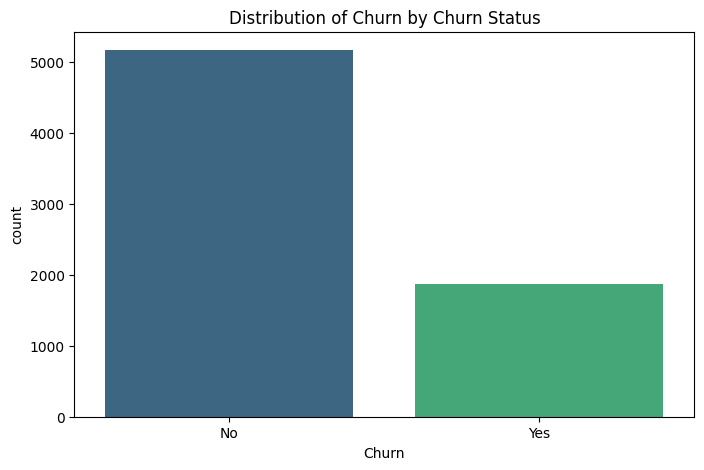

In [208]:
# Distribution of Churn by Churn Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Churn', hue='Churn', palette='viridis')
plt.title(f'Distribution of Churn by Churn Status')
plt.show()

Observation: The majority of customers did not churn, with the count of "No" significantly exceeding that of "Yes", indicating an **imbalanced dataset** where churned customers form a smaller proportion.

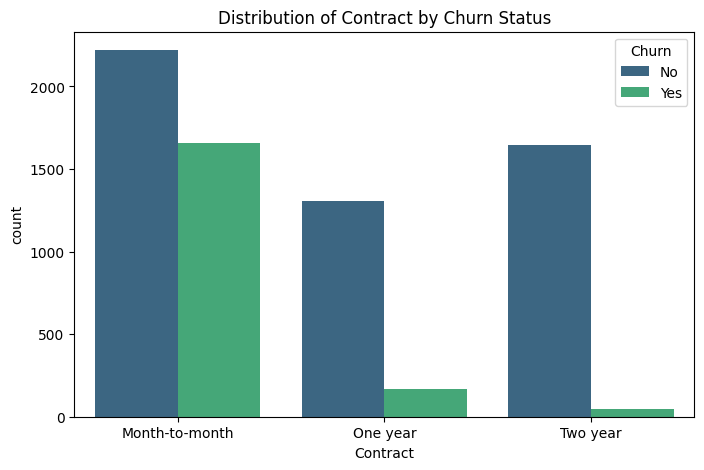

In [209]:
# Distribution of Contract by Churn Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title(f'Distribution of Contract by Churn Status')
plt.show()

Observation: Churn is most prevalent among customers with **month-to-month contracts**, while those with longer-term contracts (one and two years) show significantly lower churn rates.

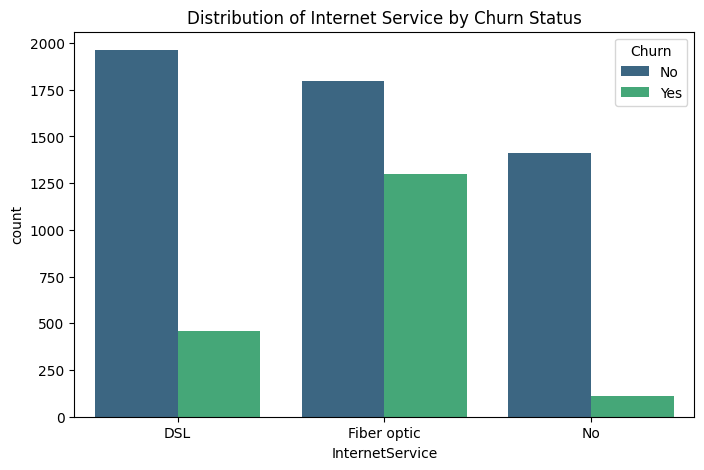

In [210]:
# Distribution of Internet Service by Churn Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='viridis')
plt.title(f'Distribution of Internet Service by Churn Status')
plt.show()

Observation: Customers with **fiber optic internet service** have a noticeably higher churn count compared to those with DSL or no internet service.

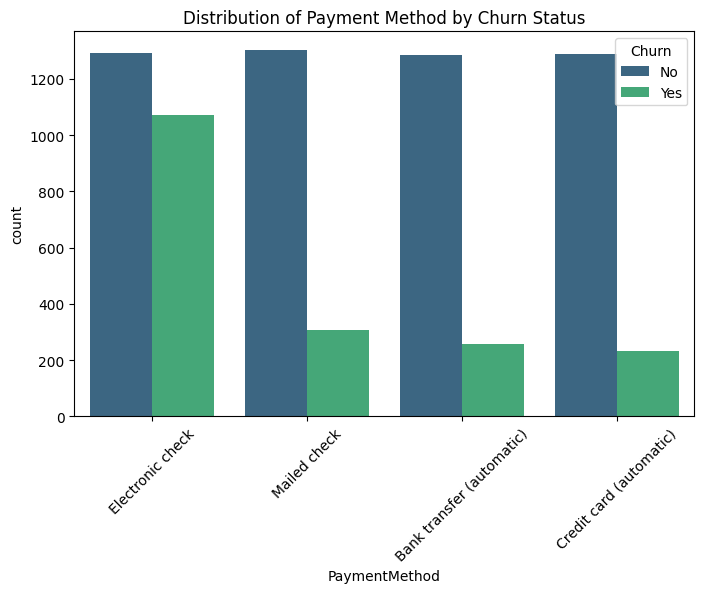

In [211]:
# Distribution of Payment Method by Churn Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='viridis')
plt.title(f'Distribution of Payment Method by Churn Status')
plt.xticks(rotation=45)
plt.show()

Observation: Customers using **electronic checks** as their payment method show a substantially higher churn count compared to those using automatic methods (bank transfer or credit card) or mailed checks.

### 5.2 Numerical features

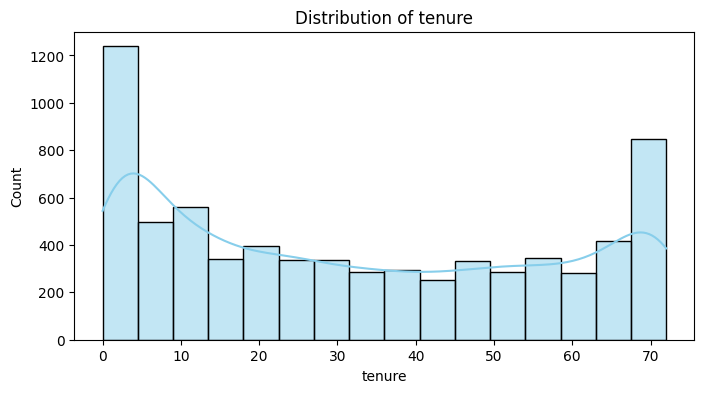

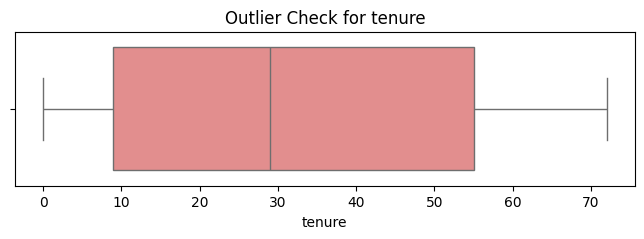

In [212]:
# Figure for Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['tenure'], kde=True, color='skyblue')
plt.title(f'Distribution of tenure')
plt.show()

# Figure for Outliers
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['tenure'], color='lightcoral')
plt.title(f'Outlier Check for tenure')
plt.show()

Observation: The distribution shows a high number of customers with very short tenure (0-10 months), followed by a relatively stable but lower count for mid-range tenures, and then a notable increase in customer counts for long-tenure groups (60-70 months).

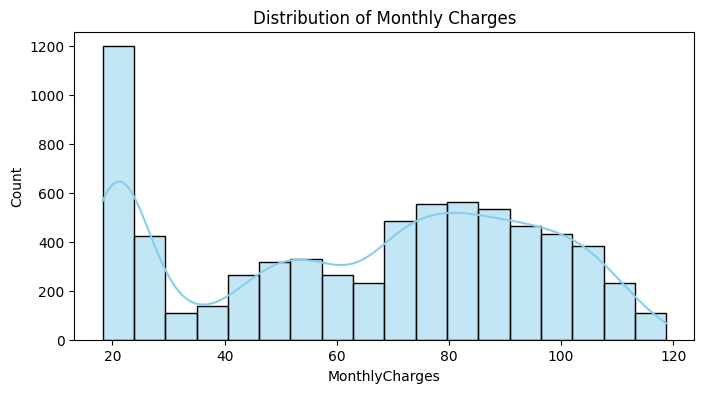

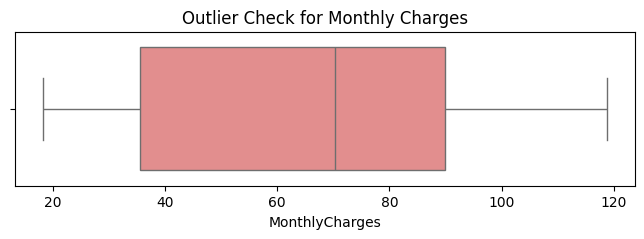

In [213]:
# Figure for Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['MonthlyCharges'], kde=True, color='skyblue')
plt.title(f'Distribution of Monthly Charges')
plt.show()

# Figure for Outliers
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['MonthlyCharges'], color='lightcoral')
plt.title(f'Outlier Check for Monthly Charges')
plt.show()

Observation: The distribution of monthly charges appears bimodal, with peaks around the lower range (approximately 20-30) and the higher range (approximately 80-100), suggesting distinct customer segments with different spending levels.

## 6. Data Preprocessing

### 6.1 Correcting data types

Here we can notice that the column 'TotalCharges' is an object instead of float. We first convert it.

In [214]:
print("Number of whitespace values in 'TotalCharges': ", df['TotalCharges'].str.isspace().sum())

Number of whitespace values in 'TotalCharges':  11


In [215]:
# Look at the rows where TotalCharges is whitespace
print(df[df['TotalCharges'] == " "][['tenure', 'MonthlyCharges', 'TotalCharges']])

      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25             
936        0           80.85             
1082       0           25.75             
1340       0           56.05             
3331       0           19.85             
3826       0           25.35             
4380       0           20.00             
5218       0           19.70             
6670       0           73.35             
6754       0           61.90             


Since these are new customers, it is mathematically sound to set their TotalCharges to 0

In [216]:
# Convert to numeric and force the whitespaces to NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill those 11 NaN values with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [217]:
# Now it is a float and you can check for outliers!
print("New data type of 'TotalCharges': ", df['TotalCharges'].dtype)

New data type of 'TotalCharges':  float64


We will now visualize this feature of 'TotalCharges'

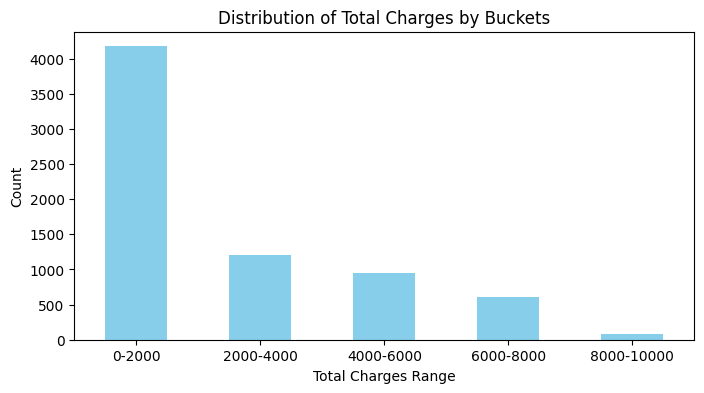

In [218]:
# Since the values have a range of 18 to 8000, we create buckets with custom bins and labels
bins = [0, 2000, 4000, 6000, 8000, 10000]
labels = ['0-2000', '2000-4000', '4000-6000', '6000-8000', '8000-10000']
df['TotalCharges_buckets'] = pd.cut(df['TotalCharges'], bins=bins, labels=labels)

# Figure for Distribution with buckets
plt.figure(figsize=(8, 4))
df['TotalCharges_buckets'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Total Charges by Buckets')
plt.xlabel('Total Charges Range')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# drop the bucket column as it was just for visualization
df.drop('TotalCharges_buckets', axis=1, inplace=True)

Observation: The distribution of total charges is **heavily skewed towards the lowest bucket** (0-2000), with the count decreasing sharply as total charges increase, indicating that most customers have relatively low cumulative charges. 

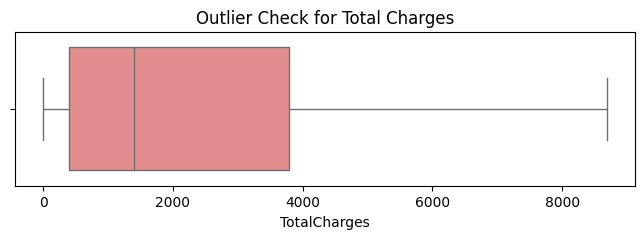

In [219]:
# Figure for Outliers
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['TotalCharges'], color='lightcoral')
plt.title(f'Outlier Check for Total Charges')
plt.show()

while there may be some extreme values, the majority of data points are concentrated within the lower range without significant outliers

### 6.2 Check for missing and duplicate values

In [220]:
# Check for any missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [221]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows: ", duplicates)

Number of duplicate rows:  0


### 6.3 Boolean Simplification

The following columns have three values: 'Yes', 'No' and **'No internet service'**:
OnlineSecurity	OnlineBackup	DeviceProtection	TechSupport	StreamingTV	StreamingMovies


Here we can treat "No internet service" as "No" because from a churn perspective, the value is in whether they have the service or not, and not because they don't having it because they don't have internet vs. not having it because they declined it.



In [222]:
# Example of simplifying those columns
sub_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

print(f"Unique values in {'StreamingMovies'} (before): {df['StreamingMovies'].unique()}")
for col in sub_services:
    df[col] = df[col].replace('No internet service', 'No')

print(f"Unique values in {'StreamingMovies'} (after): {df['StreamingMovies'].unique()}")

Unique values in StreamingMovies (before): ['No' 'Yes' 'No internet service']
Unique values in StreamingMovies (after): ['No' 'Yes']


In [223]:
# Similarly we do boolean simplification for MultipleLines
print(f"Unique values in MultipleLines (before): {df['MultipleLines'].unique()}")
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
print(f"Unique values in MultipleLines (after): {df['MultipleLines'].unique()}")

Unique values in MultipleLines (before): ['No phone service' 'No' 'Yes']
Unique values in MultipleLines (after): ['No' 'Yes']


### 6.4 Label Encoding

For all the **Binary Features** that has only two possible values (Yes/No, Male/Female), we convert them into 0s and 1s without expanding the width of your dataframe.

* gender -> Male - 1, Female - 0
* And for the rest of the columns -> Yes - 1, No - 0

In [224]:
# Encode binary features using LabelEncoder
le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService','MultipleLines', 'PaperlessBilling', 'Churn',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection','TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


## 7. Feature Engineering

### 7.1 New columnn from opted internet services

In [225]:
df['services_score'] = df[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']].sum(axis=1)

df['services_score'].head()

0    1
1    2
2    2
3    3
4    0
Name: services_score, dtype: int64

In [226]:
df_copy = df.copy()
# Dropping the ones that we combined
df.drop(columns=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'], inplace=True)

### 7.2 New column based on contract type

In [227]:
# Month-to-month becomes 1
# One year / Two year becomes
df['has_monthly_contract'] = df['Contract'].apply(lambda x: 1 if x == 'Month-to-month' else 0)

# Now you can drop the original 'Contract' column to avoid redundancy
df.drop('Contract', axis=1, inplace=True)

In [228]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,services_score,has_monthly_contract
0,7590-VHVEG,0,0,1,0,1,0,0,DSL,1,Electronic check,29.85,29.85,0,1,1
1,5575-GNVDE,1,0,0,0,34,1,0,DSL,0,Mailed check,56.95,1889.50,0,2,0
2,3668-QPYBK,1,0,0,0,2,1,0,DSL,1,Mailed check,53.85,108.15,1,2,1
3,7795-CFOCW,1,0,0,0,45,0,0,DSL,0,Bank transfer (automatic),42.30,1840.75,0,3,0
4,9237-HQITU,0,0,0,0,2,1,0,Fiber optic,1,Electronic check,70.70,151.65,1,0,1


### Checking correlation to keep relevant features

                        gender  SeniorCitizen   Partner  Dependents    tenure  \
gender                1.000000      -0.001874 -0.001808    0.010517  0.005106   
SeniorCitizen        -0.001874       1.000000  0.016479   -0.211185  0.016567   
Partner              -0.001808       0.016479  1.000000    0.452676  0.379697   
Dependents            0.010517      -0.211185  0.452676    1.000000  0.159712   
tenure                0.005106       0.016567  0.379697    0.159712  1.000000   
PhoneService         -0.006488       0.008576  0.017706   -0.001762  0.008448   
MultipleLines        -0.008414       0.142948  0.142057   -0.024526  0.331941   
PaperlessBilling     -0.011754       0.156530 -0.014877   -0.111377  0.006152   
MonthlyCharges       -0.014569       0.220173  0.096848   -0.113890  0.247900   
TotalCharges         -0.000080       0.103006  0.317504    0.062078  0.826178   
Churn                -0.008612       0.150889 -0.150448   -0.164221 -0.352229   
services_score       -0.0154

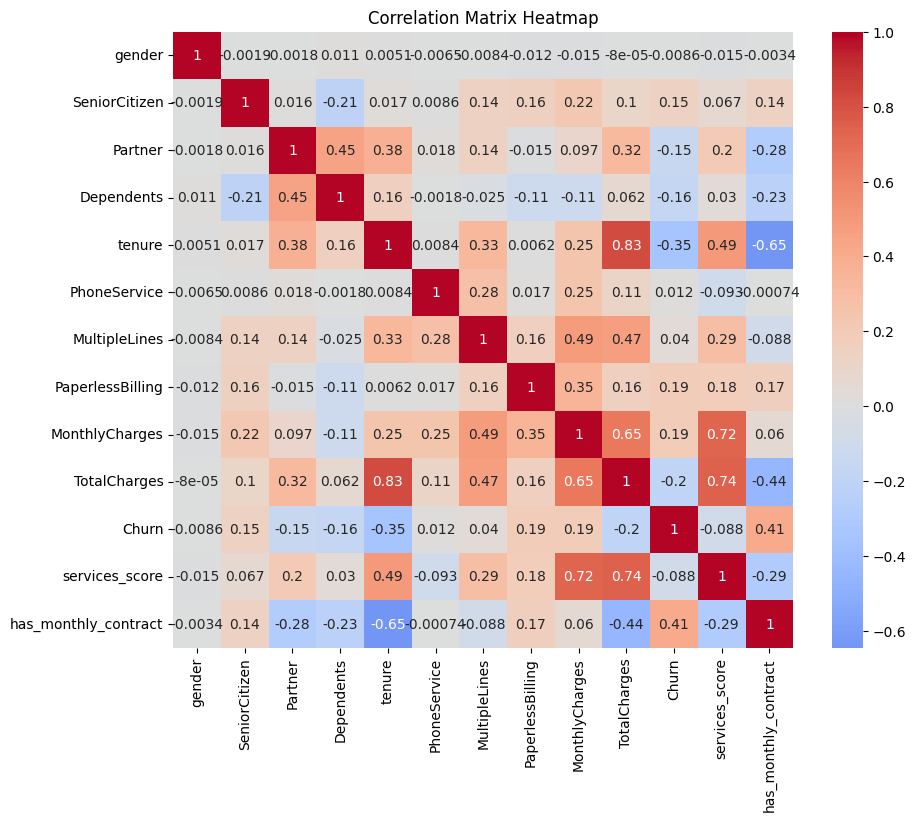

In [229]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix Heatmap')
plt.show()

Observation: The correlation between TotalCharges and tenure is 0.83, this is very high. TotalCharges is essentially a mathematical derivative of tenure and MonthlyCharges. 

Correlation of gender with churn is -0.008, very low

In [230]:
# Drop unnecessary columns

# CustomerID is just an identifier
# gender is not relevant for churn prediction in this case
# TotalCharges is redundant since we have MonthlyCharges and tenure
df = df.drop(columns=['customerID','gender','TotalCharges'], axis=1)

### 7.3 One Hot Encoding (OHE)

In [231]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False
                        , drop='first'
                        )
encoded_array = encoder.fit_transform(df[['PaymentMethod','InternetService']])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['PaymentMethod',  'InternetService']))

new_df = pd.concat([df, encoded_df], axis=1)
new_df.drop(columns=['PaymentMethod', 'InternetService'], inplace=True)

In [232]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   MultipleLines                          7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   Churn                                  7043 non-null   int64  
 9   services_score                         7043 non-null   int64  
 10  has_monthly_contract                   7043 non-null   int64  
 11  Paym

## 8. Experiment Design

1. Start: Logistic Regression (baseline)

   ↓

2. Compare: XGBoost with default values vs SMOTE

   ↓

3. SHAP for explainability


Models chosen:

I am implementing **Logistic Regression** as an <u>interpretable baseline</u> and **XGBoost** as a <u>high-performance ensemble method</u> to capture non-linear relationships. While XGBoost is compared against LightGBM, it was selected for this 7,043-record dataset due to its superior regularization and stable performance when combined with SMOTE to handle class imbalance.

Evaluation metrics:

Given the imbalanced nature of the data, I am prioritizing Recall and the F1-Score over Accuracy to ensure the model effectively identifies potential churners while maintaining a healthy balance between detection and precision. These metrics directly inform the subsequent steps of model fine-tuning and the evaluation of business impact through SHAP explainability

## 9. Data Preparation

In [233]:
# Define Features and Target
X = new_df.drop('Churn', axis=1)
y = new_df['Churn']

# 80-20 Split with Stratify to maintain churn proportion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [234]:
X_train.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,services_score,has_monthly_contract,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
3738,0,0,0,35,0,0,0,49.20,3,1,0.0,1.0,0.0,0.0,0.0
3151,0,1,1,15,1,0,0,75.10,1,1,0.0,0.0,1.0,1.0,0.0
4860,0,1,1,13,0,0,0,40.55,3,0,0.0,0.0,1.0,0.0,0.0
3867,0,1,0,26,1,0,1,73.50,4,0,1.0,0.0,0.0,0.0,0.0
3810,0,1,1,1,1,0,0,44.55,0,1,0.0,1.0,0.0,0.0,0.0


## 10. Data Modelling

In [235]:
# Logistic Regression works best with scaled data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# Evaluation
y_pred_log = log_model.predict(X_test_scaled)
print("Logistic Regression done")

Logistic Regression done


In [236]:
from xgboost import XGBClassifier

# Experiment 2: Raw data
# xgb_raw = XGBClassifier(random_state=42, eval_metric='logloss')

pos = y_train.sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / max(pos, 1)

xgb_raw = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    min_child_weight=1,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight # scale_pos_weight helps when class imbalance exists
)
xgb_raw.fit(X_train, y_train)

y_pred_xgb_raw = xgb_raw.predict(X_test)
print("XGBoost (Raw) done")

XGBoost (Raw) done


In [237]:
# Scaling
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

# Applying SMOTE to the MinMax scaled data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_mm, y_train)

# Experiment 3: Balanced data
xgb_smote = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.5,
    reg_alpha=0.5,
    random_state=42,
    eval_metric='logloss'
)
xgb_smote.fit(X_train_res, y_train_res)

y_pred_xgb_smote = xgb_smote.predict(X_test_mm)
print("XGBoost (SMOTE) done")

XGBoost (SMOTE) done


## 11. Model Evaluation

In [238]:
print("--- Logistic Regression Results")
print(classification_report(y_test, y_pred_log))

print("--- XGBoost (Raw) Results:")
print(classification_report(y_test, y_pred_xgb_raw))

print("--- XGBoost (SMOTE) Results:")
print(classification_report(y_test, y_pred_xgb_smote))

--- Logistic Regression Results
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

--- XGBoost (Raw) Results:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409

--- XGBoost (SMOTE) Results:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1035
           1       0.56      0.68      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0

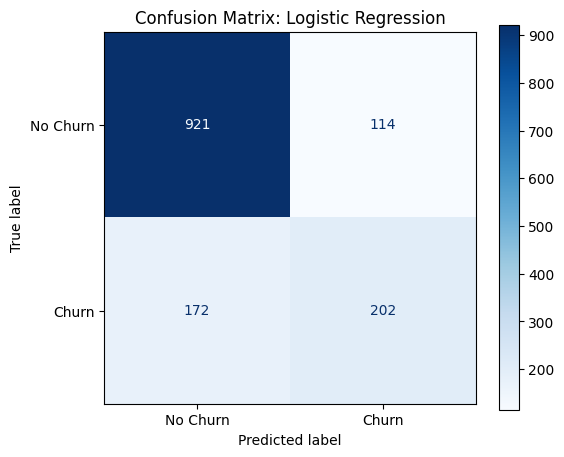

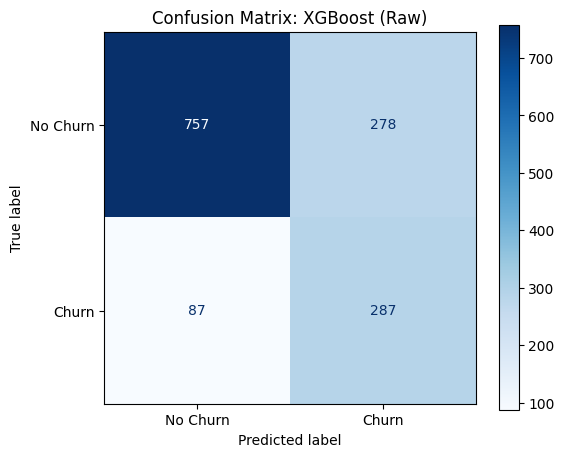

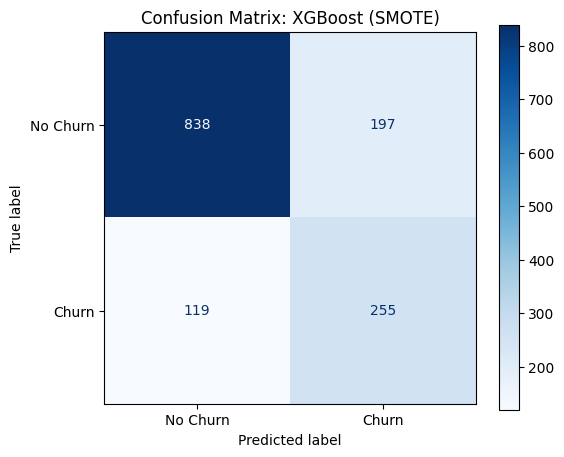

In [239]:
# List of your models and their corresponding test data
model_list = [
    ("Logistic Regression", log_model, X_test_scaled),
    ("XGBoost (Raw)", xgb_raw, X_test),
    ("XGBoost (SMOTE)", xgb_smote, X_test_mm)
]

for title, model, data in model_list:
    # Create a new figure for each matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_estimator(
        model, data, y_test, 
        display_labels=['No Churn', 'Churn'], 
        cmap='Blues', 
        ax=ax
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.grid(False) # Clean up the look
    plt.show()

**Observations**

XGBoost (Raw)

    This is the highest recall in experiment. We are missing very few people who are leaving.

    The precision dropped to 0.51. This means that when the model says "This person will churn," it’s essentially a coin flip—only half of them actually leave. This could lead to expensive marketing over-spend on loyal customers.

XGBoost (SMOTE)

    The F1-Score: At 0.62, this is your best-performing model overall. It provides the most mathematically stable balance between catching churners and not being wrong too often.

    Accuracy: At 78%, it is much more reliable than the Raw XGBoost (74%) while still maintaining a healthy recall of 0.68.

## 12. Model Explainability

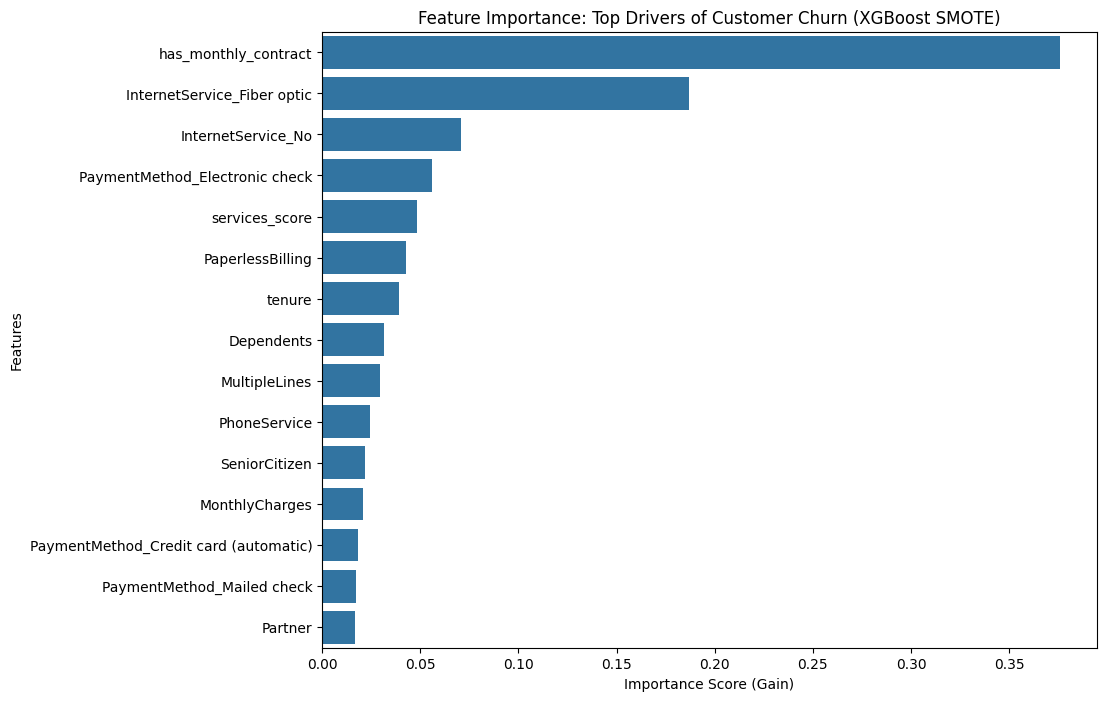

In [240]:
# Get feature importance from the SMOTE model
importances = xgb_smote.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance: Top Drivers of Customer Churn (XGBoost SMOTE)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.show()

**Observations**

* Customers on **month-to-month contracts** are far more likely to churn than those locked into longer agreements.

* **Fibre optic users** have high churn, this often indicates:

    Higher price sensitivity,

    Service quality expectations,

    Competitive alternatives in high-speed markets.

* **Electronic check users** churn more suggesting that manual payment methods correlate with weaker commitment

* Regarding **tenure**, we can see that churn is not just about how long someone stayed, but also about contract flexibility and service type

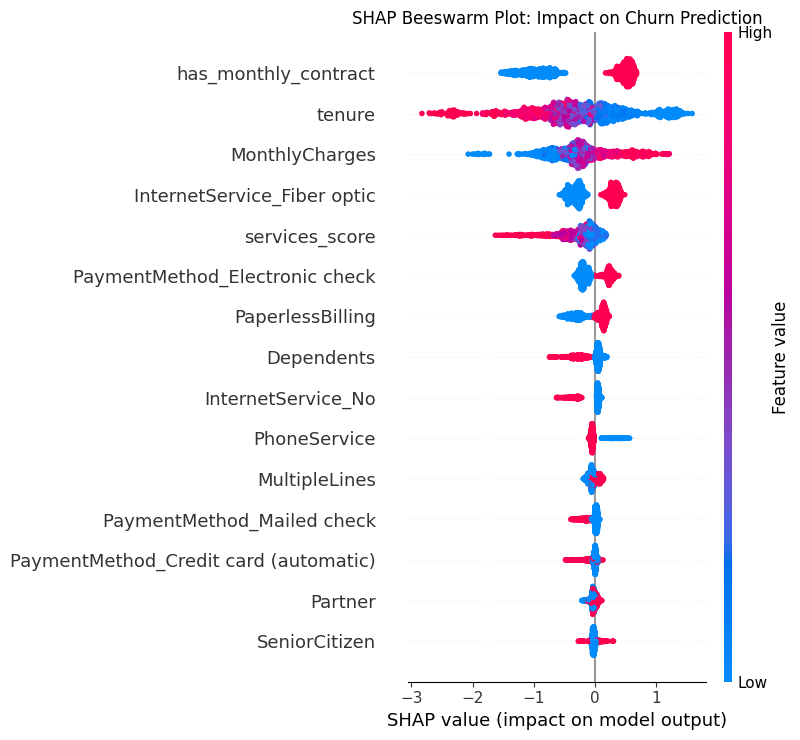

In [241]:
import shap

explainer = shap.TreeExplainer(xgb_smote)

# We use X_test_mm because the SMOTE model was trained on MinMax scaled data
shap_values = explainer.shap_values(X_test_mm)

plt.title('SHAP Beeswarm Plot: Impact on Churn Prediction')
shap.summary_plot(shap_values, X_test_mm, feature_names=X.columns)

**Observations**

* Month-to-Month Contracts Strongly Increase Churn Risk
* Short Tenure Customers Are Much More Likely to Churn
* Higher Monthly Charges Push Customers Toward Churn
* Fiber Optic Customers Show Elevated Churn Sensitivity
* Low Service Engagement (Low services_score) Drives Churn
* Electronic Check Payment Is a Churn Risk Indicator

## 13. Recommendations

1. (From Contract) Convert Month-to-Month Customers Into Contract Plans

Actions: 

    Offer discounts for upgrading to 12–24 month contracts.

2. (From tenure) Focus Retention Efforts in the First 90–120 Days

Actions:

    Launch onboarding success programs.

    Send proactive check-ins after installation.

    Offer early satisfaction surveys + instant support resolution.

3. (From Monthly charges) Reframe Pricing Around Value, Not Discounts

Actions:

    Provide usage insights (“You streamed X hours this month”).

    Bundle services rather than lowering price.

4. (From Internet service) Create Premium Support for Fiber Optic Users

Actions:

    Priority technical support for fiber customers.

    Network performance guarantees or credits.

    Proactive outage communication.

5. (From additional internet services) Increase Customer 'Stickiness' Through Service Bundling

Actions:

    Cross-sell security, streaming, backup, or family plans.

    Offer bundle discounts once a customer adopts ≥2 services.

## 14. Slack integration

In [242]:
X_for_scoring = X_test 
indices = X_test.index

# Use the scaler fitted on X_train
X_scored_scaled = mm_scaler.transform(X_for_scoring)

# using best model (XGBoost SMOTE) to predict probabilities
best_probs = xgb_smote.predict_proba(X_scored_scaled)[:, 1]

# We use the original dataframe to keep features readable (e.g., 'Yes/No' instead of 1/0)
df_alert = df_copy.loc[indices].copy()
df_alert["churn_risk_score"] = best_probs

# Filter for High-Risk (Probability >= 70%)
RISK_THRESHOLD = 0.70
high_risk = (
    df_alert[df_alert["churn_risk_score"] >= RISK_THRESHOLD]
    .sort_values("churn_risk_score", ascending=False)
)

print(f"Total Test Customers Analyzed: {len(df_alert)}")
print(f"High-Risk Customers Identified: {high_risk.shape[0]}")

# Display for your report
high_risk[['customerID', 'tenure', 'MonthlyCharges', 'churn_risk_score']].head(10)

Total Test Customers Analyzed: 1409
High-Risk Customers Identified: 242


,customerID,tenure,MonthlyCharges,churn_risk_score
4585,1069-XAIEM,1,85.05,0.970899
2631,6861-XWTWQ,7,99.25,0.963463
1073,0655-RBDUG,7,98.05,0.955408
6866,0295-PPHDO,1,95.45,0.955380
6623,9248-OJYKK,1,76.45,0.954819
2464,2609-IAICY,1,77.15,0.952395
3380,5178-LMXOP,1,95.10,0.952288
3346,2545-EBUPK,2,84.05,0.945167
2350,8739-XNIKG,5,84.00,0.945080
2194,2514-GINMM,1,79.50,0.944917


In [243]:
SLACK_WEBHOOK_URL = os.getenv("SLACK_WEBHOOK_URL") 

def send_churn_alert(message: str):
    """Sends a formatted alert to the Slack retention channel."""
    if not SLACK_WEBHOOK_URL:
        print("Alert skipped: Slack Webhook URL not configured.")
        return
    
    payload = {"text": message}
    try:
        response = requests.post(SLACK_WEBHOOK_URL, json=payload, timeout=10)
        if response.status_code == 200:
            print(f"Successfully sent alert: {message[:50]}...")
        else:
            print(f"Failed to send alert. Status: {response.status_code}")
    except Exception as e:
        print(f"An error occurred while sending the alert: {e}")


# We notify the team about the Top 5 customers most likely to leave
top_alerts_count = min(5, high_risk.shape[0])

print(f"Triggering {top_alerts_count} high-priority alerts...")

for i in range(top_alerts_count):
    customer_data = high_risk.iloc[i]
    
    # Building the alert message with insights from our EDA/SHAP analysis
    alert_msg = (
        f" *CHURN RISK ALERT: HIGH PRIORITY* \n"
        f"• *Customer ID:* `{customer_data['customerID']}`\n"
        f"• *Risk Probability:* `{customer_data['churn_risk_score']:.2%}`\n"
        f"• *Contract Type:* {customer_data['Contract']}\n"
        f"• *Tenure:* {customer_data['tenure']} months\n"
    )
    
    send_churn_alert(alert_msg)

Triggering 5 high-priority alerts...
Successfully sent alert:  *CHURN RISK ALERT: HIGH PRIORITY* 
• *Customer ID...
Successfully sent alert:  *CHURN RISK ALERT: HIGH PRIORITY* 
• *Customer ID...
Successfully sent alert:  *CHURN RISK ALERT: HIGH PRIORITY* 
• *Customer ID...
Successfully sent alert:  *CHURN RISK ALERT: HIGH PRIORITY* 
• *Customer ID...
Successfully sent alert:  *CHURN RISK ALERT: HIGH PRIORITY* 
• *Customer ID...
